# U-Net Batch Inference — Guwahati Sentinel-2 (3 Years)
Processes all chip folders (`YYYYMMDD`) in the dataset directory.  
Each chip contains `B02.tif`, `B03.tif`, `B04.tif`, `B08.tif`.  
Outputs per-chip prediction masks + aggregate CSV + summary plots.

> **Model**: U-Net (same architecture as trained in `U-Net_30_Epoch.ipynb`)

## Imports

In [2]:
import os
import re
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import rasterio
import torch
import torch.nn as nn
import torchvision.transforms.functional as TF
from datetime import datetime
from pathlib import Path
from tqdm import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


## Configuration — edit these paths

In [3]:
# ─── EDIT THESE ───────────────────────────────────────────────────────────────
DATASET_DIR  = r"D:\Documents\AEC\FInal Year Project\test tempppp"   # root folder containing YYYYMMDD chip folders
MODEL_PATH   = "pytorch_unet_cloud_30epochfix_256img.pth"       # path to your trained U-Net weights (.pth)
OUTPUT_DIR   = r"D:\ML\env\notebook\Results\results_unet"           # where CSVs and plots will be saved
SAVE_MASKS   = True                     # save per-chip prediction mask PNGs
SAVE_PLOTS   = True                     # save per-chip side-by-side RGB+mask plots
THRESHOLD    = 0.5                      # cloud probability threshold (matches training)
IMG_SIZE     = 256                      # must match training image size
I_MAX        = 1000.0                   # max solar irradiance W/m²
ALPHA        = 0.8                      # irradiance attenuation coefficient
# ──────────────────────────────────────────────────────────────────────────────

BANDS = ['B02', 'B03', 'B04', 'B08']

os.makedirs(OUTPUT_DIR, exist_ok=True)
if SAVE_MASKS:
    os.makedirs(os.path.join(OUTPUT_DIR, 'masks'), exist_ok=True)
if SAVE_PLOTS:
    os.makedirs(os.path.join(OUTPUT_DIR, 'plots'), exist_ok=True)

print(f"Dataset : {DATASET_DIR}")
print(f"Model   : {MODEL_PATH}")
print(f"Output  : {OUTPUT_DIR}")

Dataset : D:\Documents\AEC\FInal Year Project\test tempppp
Model   : pytorch_unet_cloud_30epochfix_256img.pth
Output  : D:\ML\env\notebook\Results\results_unet


## U-Net Model Definition
Identical architecture to `U-Net_30_Epoch.ipynb` — must match exactly for weights to load correctly.

In [4]:
class DoubleConv(nn.Module):
    """Two consecutive Conv2d → ReLU blocks."""
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    """
    U-Net for 4-band Sentinel-2 input (B02, B03, B04, B08).
    Input  : (B, 4, 256, 256)
    Output : (B, 1, 256, 256)  — sigmoid probability map
    """
    def __init__(self, in_channels=4, out_channels=1):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.up   = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        # Encoder
        self.c1 = DoubleConv(in_channels, 16)
        self.c2 = DoubleConv(16, 32)
        self.c3 = DoubleConv(32, 64)
        self.c4 = DoubleConv(64, 128)

        # Bottleneck
        self.bn = DoubleConv(128, 256)

        # Decoder
        self.c5 = DoubleConv(256 + 128, 128)
        self.c6 = DoubleConv(128 + 64,  64)
        self.c7 = DoubleConv(64  + 32,  32)
        self.c8 = DoubleConv(32  + 16,  16)

        self.out = nn.Sequential(
            nn.Conv2d(16, out_channels, kernel_size=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # Encoder path
        c1 = self.c1(x);  p1 = self.pool(c1)
        c2 = self.c2(p1); p2 = self.pool(c2)
        c3 = self.c3(p2); p3 = self.pool(c3)
        c4 = self.c4(p3); p4 = self.pool(c4)

        # Bottleneck
        bn = self.bn(p4)

        # Decoder path with skip connections
        u4 = self.up(bn);  u4 = torch.cat([u4, c4], dim=1); c5 = self.c5(u4)
        u3 = self.up(c5);  u3 = torch.cat([u3, c3], dim=1); c6 = self.c6(u3)
        u2 = self.up(c6);  u2 = torch.cat([u2, c2], dim=1); c7 = self.c7(u2)
        u1 = self.up(c7);  u1 = torch.cat([u1, c1], dim=1); c8 = self.c8(u1)

        return self.out(c8)


print("✅ U-Net architecture defined")

✅ U-Net architecture defined


## Load Trained Model

In [5]:
model = UNet(in_channels=4, out_channels=1)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model = model.to(device)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"✅ U-Net loaded from: {MODEL_PATH}")
print(f"   Parameters: {total_params:,}")

✅ U-Net loaded from: pytorch_unet_cloud_30epochfix_256img.pth
   Parameters: 1,962,769


## Helper Functions

In [6]:
def load_chip(chip_dir: str):
    """
    Load B02/B03/B04/B08 bands from a chip folder.
    Returns a numpy array of shape (H, W, 4) float32, or None if any band is missing.
    """
    bands = []
    for band in BANDS:
        path = os.path.join(chip_dir, f"{band}.tif")
        if not os.path.isfile(path):
            return None
        with rasterio.open(path) as src:
            bands.append(src.read(1).astype(np.float32))
    return np.stack(bands, axis=-1)  # (H, W, 4)


def preprocess(image: np.ndarray) -> torch.Tensor:
    """
    Normalize to [0, 1] and resize to IMG_SIZE × IMG_SIZE.
    Matches the CloudDataset preprocessing used during training.
    Returns a tensor of shape (1, 4, IMG_SIZE, IMG_SIZE).
    """
    image = image / 65535.0                                  # scale to [0, 1]
    tensor = torch.from_numpy(image).permute(2, 0, 1)        # (4, H, W)
    tensor = TF.resize(tensor, [IMG_SIZE, IMG_SIZE], antialias=True)
    return tensor.unsqueeze(0).float().to(device)            # (1, 4, IMG_SIZE, IMG_SIZE)


def predict(tensor: torch.Tensor) -> np.ndarray:
    """
    Run U-Net inference and return a binary mask of shape (H, W).
    """
    with torch.no_grad():
        output = model(tensor)                               # (1, 1, H, W) — sigmoid output
        mask = (output > THRESHOLD).float()
    return mask[0, 0].cpu().numpy()                         # (H, W)


def compute_metrics(mask: np.ndarray, I_max: float = I_MAX, alpha: float = ALPHA):
    """Return cloud cover (%) and estimated solar irradiance (W/m²)."""
    cloud_pct  = (np.sum(mask) / mask.size) * 100.0
    irradiance = max(I_max * (1 - alpha * cloud_pct / 100.0), 0.0)
    return cloud_pct, irradiance


def to_rgb(tensor_4band: torch.Tensor) -> np.ndarray:
    """
    Convert (4, H, W) tensor to display-ready (H, W, 3) RGB using B04→R, B03→G, B02→B.
    """
    img = tensor_4band.cpu().numpy()         # (4, H, W)
    rgb = img[[2, 1, 0], :, :]               # select B04, B03, B02
    rgb = np.transpose(rgb, (1, 2, 0))       # (H, W, 3)
    rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-8)
    return rgb


def is_chip_folder(name: str) -> bool:
    """Return True if folder name matches YYYYMMDD pattern."""
    return bool(re.fullmatch(r'\d{8}', name))


def parse_date(name: str) -> datetime:
    return datetime.strptime(name, '%Y%m%d')


print("✅ Helper functions ready")

✅ Helper functions ready


## Discover Chip Folders

In [7]:
all_entries  = sorted(os.listdir(DATASET_DIR))
chip_folders = [
    e for e in all_entries
    if is_chip_folder(e) and os.path.isdir(os.path.join(DATASET_DIR, e))
]

print(f"Found {len(chip_folders)} chip folders")
if chip_folders:
    print(f"  Date range : {chip_folders[0]}  →  {chip_folders[-1]}")
    print(f"  Sample     : {chip_folders[:5]}")

Found 1 chip folders
  Date range : 20241226  →  20241226
  Sample     : ['20241226']


## Batch Inference Loop

In [8]:
results = []   # list of dicts → CSV
skipped = []   # chip IDs with missing bands

for chip_id in tqdm(chip_folders, desc="Processing chips"):
    chip_dir = os.path.join(DATASET_DIR, chip_id)

    # ── Load ──────────────────────────────────────────────────────────────────
    image = load_chip(chip_dir)
    if image is None:
        skipped.append(chip_id)
        tqdm.write(f"  ⚠ Skipped {chip_id} — missing band file(s)")
        continue

    # ── Preprocess & predict ──────────────────────────────────────────────────
    tensor    = preprocess(image)   # (1, 4, 256, 256)
    mask      = predict(tensor)     # (256, 256) binary

    # ── Metrics ───────────────────────────────────────────────────────────────
    cloud_pct, irradiance = compute_metrics(mask)
    date_obj = parse_date(chip_id)

    results.append({
        'chip_id'        : chip_id,
        'date'           : date_obj.strftime('%Y-%m-%d'),
        'year'           : date_obj.year,
        'month'          : date_obj.month,
        'day'            : date_obj.day,
        'cloud_cover_pct': round(cloud_pct, 4),
        'irradiance_wm2' : round(irradiance, 4),
    })

    # ── Optional: save binary mask as PNG ─────────────────────────────────────
    if SAVE_MASKS:
        mask_path = os.path.join(OUTPUT_DIR, 'masks', f"{chip_id}_mask.png")
        plt.imsave(mask_path, mask, cmap='gray')

    # ── Optional: save side-by-side RGB + mask plot ───────────────────────────
    if SAVE_PLOTS:
        rgb = to_rgb(tensor[0])   # tensor[0] is shape (4, H, W)

        fig, axes = plt.subplots(1, 2, figsize=(11, 5))
        axes[0].imshow(rgb)
        axes[0].set_title(f"RGB — {chip_id}")
        axes[0].axis('off')

        axes[1].imshow(mask, cmap='gray')
        axes[1].set_title(
            f"U-Net Prediction\nCloud: {cloud_pct:.2f}%   Irr: {irradiance:.1f} W/m²"
        )
        axes[1].axis('off')

        plt.tight_layout()
        fig.savefig(
            os.path.join(OUTPUT_DIR, 'plots', f"{chip_id}_result.png"),
            dpi=100, bbox_inches='tight'
        )
        plt.close(fig)

print(f"\n✅ Processed : {len(results)} chips")
print(f"⚠  Skipped   : {len(skipped)} chips {skipped if skipped else ''}")

Processing chips: 100%|██████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  1.48it/s]


✅ Processed : 1 chips
⚠  Skipped   : 0 chips 


## Save Results to CSV

In [8]:
csv_path   = os.path.join(OUTPUT_DIR, 'unet_results.csv')
fieldnames = ['chip_id', 'date', 'year', 'month', 'day', 'cloud_cover_pct', 'irradiance_wm2']

with open(csv_path, 'w', newline='') as f:
    writer = csv.DictWriter(f, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(results)

print(f"✅ CSV saved → {csv_path}")
print(f"\nFirst 5 rows:")
for r in results[:5]:
    print(f"  {r['date']}  CC={r['cloud_cover_pct']:.2f}%  Irr={r['irradiance_wm2']:.1f} W/m²")

✅ CSV saved → D:\ML\env\notebook\Results\results_unet\unet_results.csv

First 5 rows:
  2022-01-01  CC=98.68%  Irr=210.6 W/m²
  2022-01-06  CC=18.69%  Irr=850.5 W/m²
  2022-01-11  CC=99.90%  Irr=200.8 W/m²
  2022-01-16  CC=65.52%  Irr=475.8 W/m²
  2022-01-21  CC=96.08%  Irr=231.3 W/m²


## Summary Plots

In [9]:
# ── Prepare arrays ────────────────────────────────────────────────────────────
dates      = [datetime.strptime(r['date'], '%Y-%m-%d') for r in results]
cloud_vals = [r['cloud_cover_pct'] for r in results]
irr_vals   = [r['irradiance_wm2']  for r in results]

MONTH_NAMES = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

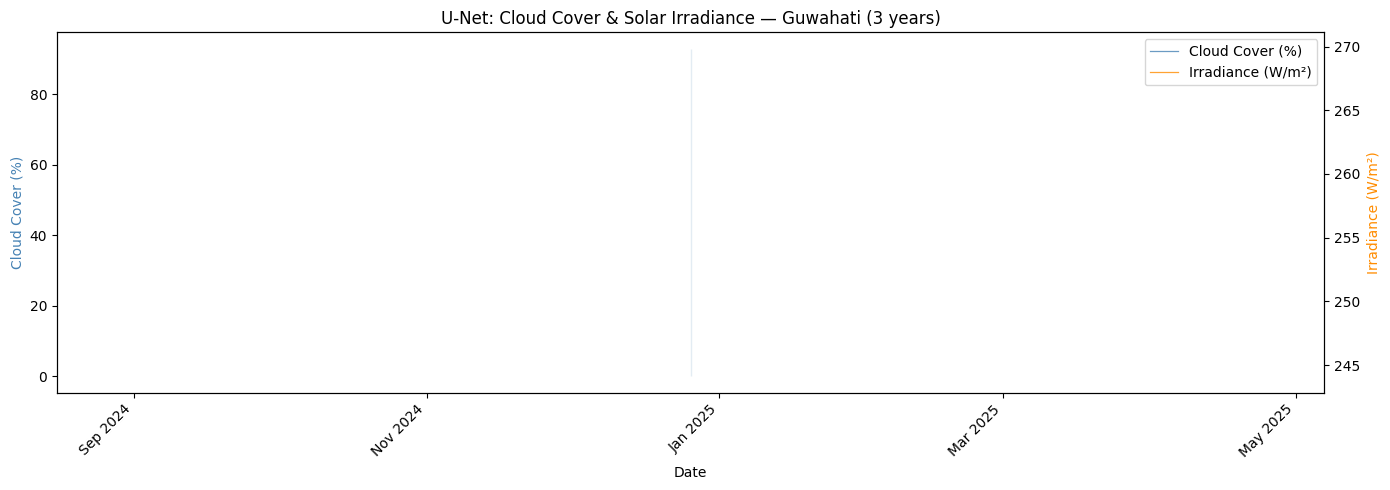

✅ Plot 1 saved


In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 1 — Time-series: cloud cover + irradiance (dual y-axis)
# ─────────────────────────────────────────────────────────────────────────────
fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()

ax1.plot(dates, cloud_vals, color='steelblue',  linewidth=0.9, alpha=0.8, label='Cloud Cover (%)')
ax1.fill_between(dates, cloud_vals, alpha=0.15, color='steelblue')
ax2.plot(dates, irr_vals,  color='darkorange',  linewidth=0.9, alpha=0.8, label='Irradiance (W/m²)')

ax1.set_ylabel('Cloud Cover (%)',    color='steelblue')
ax2.set_ylabel('Irradiance (W/m²)', color='darkorange')
ax1.set_xlabel('Date')
ax1.set_title('U-Net: Cloud Cover & Solar Irradiance — Guwahati (3 years)')
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax1.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'timeseries_cloud_irradiance.png'), dpi=150)
plt.show()
print("✅ Plot 1 saved")

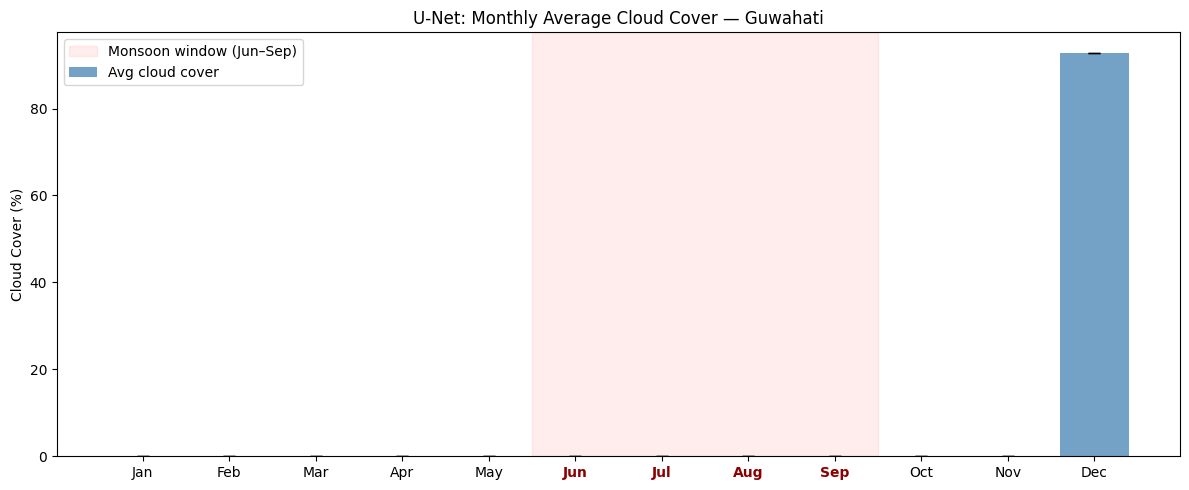

✅ Plot 2 saved


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 2 — Monthly average cloud cover (bar chart)
# ─────────────────────────────────────────────────────────────────────────────
monthly_cloud = {m: [] for m in range(1, 13)}
monthly_irr   = {m: [] for m in range(1, 13)}

for r in results:
    monthly_cloud[r['month']].append(r['cloud_cover_pct'])
    monthly_irr[r['month']].append(r['irradiance_wm2'])

avg_cloud = [np.mean(monthly_cloud[m]) if monthly_cloud[m] else 0 for m in range(1, 13)]
std_cloud = [np.std(monthly_cloud[m])  if monthly_cloud[m] else 0 for m in range(1, 13)]
avg_irr   = [np.mean(monthly_irr[m])   if monthly_irr[m]   else 0 for m in range(1, 13)]

x = np.arange(12)
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(x, avg_cloud, color='steelblue', alpha=0.75, yerr=std_cloud, capsize=4, label='Avg cloud cover')
ax.set_xticks(x)
ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel('Cloud Cover (%)')
ax.set_title('U-Net: Monthly Average Cloud Cover — Guwahati')

# Highlight monsoon months (Jun–Sep, indices 5–8)
for i in [5, 6, 7, 8]:
    ax.get_xticklabels()[i].set_color('darkred')
    ax.get_xticklabels()[i].set_fontweight('bold')

ax.axvspan(4.5, 8.5, alpha=0.07, color='red', label='Monsoon window (Jun–Sep)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'monthly_avg_cloud_cover.png'), dpi=150)
plt.show()
print("✅ Plot 2 saved")

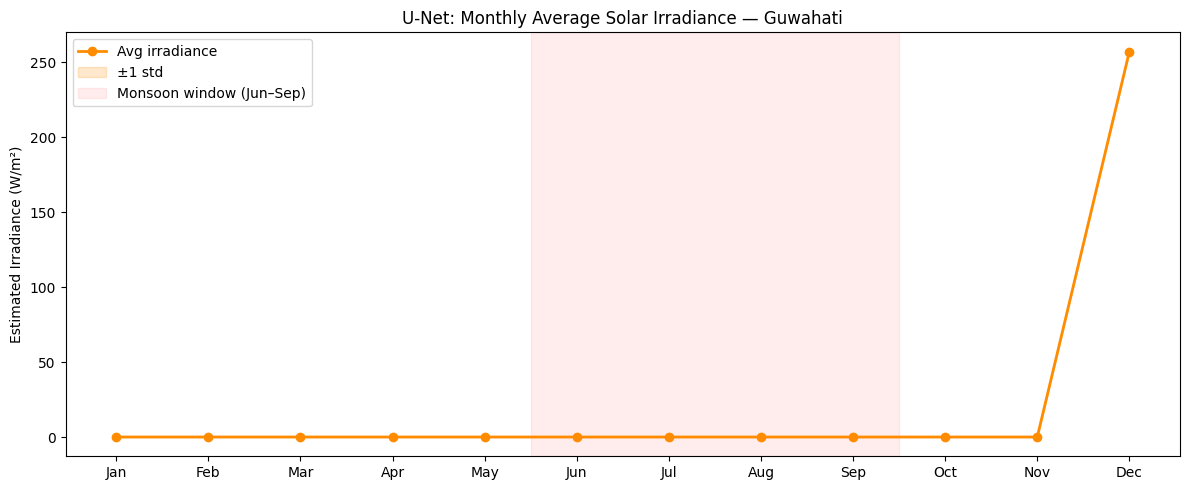

✅ Plot 3 saved


In [12]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 3 — Monthly average irradiance (line + shaded ±1 std)
# ─────────────────────────────────────────────────────────────────────────────
avg_irr_arr = np.array(avg_irr)
std_irr     = np.array([np.std(monthly_irr[m]) if monthly_irr[m] else 0 for m in range(1, 13)])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(x, avg_irr_arr, color='darkorange', marker='o', linewidth=2, label='Avg irradiance')
ax.fill_between(x, avg_irr_arr - std_irr, avg_irr_arr + std_irr,
                alpha=0.2, color='darkorange', label='±1 std')
ax.set_xticks(x)
ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel('Estimated Irradiance (W/m²)')
ax.set_title('U-Net: Monthly Average Solar Irradiance — Guwahati')
ax.axvspan(4.5, 8.5, alpha=0.07, color='red', label='Monsoon window (Jun–Sep)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'monthly_avg_irradiance.png'), dpi=150)
plt.show()
print("✅ Plot 3 saved")

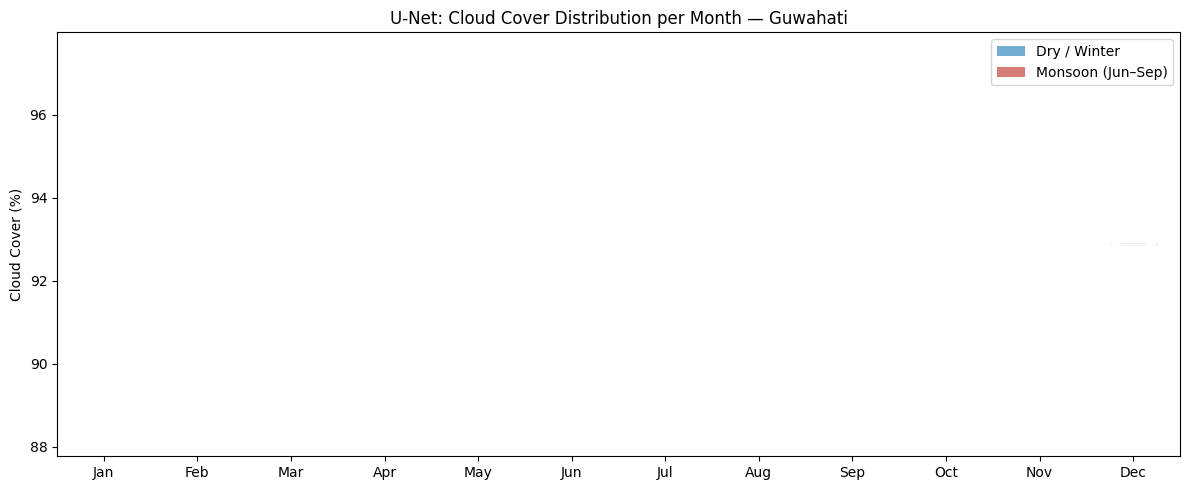

✅ Plot 4 saved


In [13]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 4 — Box plots: cloud cover distribution per month
# ─────────────────────────────────────────────────────────────────────────────
from matplotlib.patches import Patch

box_data = [monthly_cloud[m] for m in range(1, 13)]

fig, ax = plt.subplots(figsize=(12, 5))
bp = ax.boxplot(box_data, patch_artist=True,
                medianprops=dict(color='white', linewidth=2))

for i, patch in enumerate(bp['boxes']):
    patch.set_facecolor('#c0392b' if i in [5, 6, 7, 8] else '#2980b9')
    patch.set_alpha(0.65)

ax.set_xticklabels(MONTH_NAMES)
ax.set_ylabel('Cloud Cover (%)')
ax.set_title('U-Net: Cloud Cover Distribution per Month — Guwahati')
ax.legend(handles=[
    Patch(facecolor='#2980b9', alpha=0.65, label='Dry / Winter'),
    Patch(facecolor='#c0392b', alpha=0.65, label='Monsoon (Jun–Sep)'),
])
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'monthly_boxplot_cloud.png'), dpi=150)
plt.show()
print("✅ Plot 4 saved")

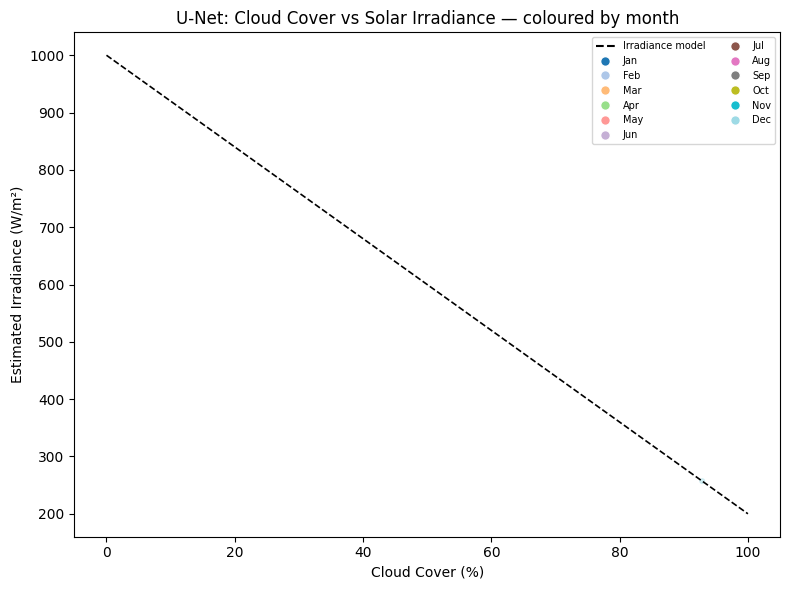

✅ Plot 5 saved


In [14]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 5 — Scatter: cloud cover vs irradiance (coloured by month)
# ─────────────────────────────────────────────────────────────────────────────
from matplotlib.lines import Line2D

month_colors    = plt.cm.tab20(np.linspace(0, 1, 12))
month_color_map = {m + 1: month_colors[m] for m in range(12)}

fig, ax = plt.subplots(figsize=(8, 6))
for r in results:
    ax.scatter(
        r['cloud_cover_pct'], r['irradiance_wm2'],
        color=month_color_map[r['month']], alpha=0.5, s=18, edgecolors='none'
    )

# Reference inverse-relation line
cc_line  = np.linspace(0, 100, 200)
irr_line = I_MAX * (1 - ALPHA * cc_line / 100)
ax.plot(cc_line, irr_line, 'k--', linewidth=1.2,
        label=f'Model: I = {I_MAX}×(1−{ALPHA}×CC/100)')

legend_els = [Line2D([0], [0], color='k', linestyle='--', label='Irradiance model')]
legend_els += [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=month_color_map[m],
           markersize=7, label=MONTH_NAMES[m - 1])
    for m in range(1, 13)
]
ax.legend(handles=legend_els, fontsize=7, ncol=2, loc='upper right')
ax.set_xlabel('Cloud Cover (%)')
ax.set_ylabel('Estimated Irradiance (W/m²)')
ax.set_title('U-Net: Cloud Cover vs Solar Irradiance — coloured by month')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'scatter_cloud_vs_irradiance.png'), dpi=150)
plt.show()
print("✅ Plot 5 saved")

In [15]:
# ─────────────────────────────────────────────────────────────────────────────
# PLOT 6 — Year-over-year comparison (cloud cover + irradiance)
# ─────────────────────────────────────────────────────────────────────────────
years = sorted(set(r['year'] for r in results))

if len(years) > 1:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for yr in years:
        yr_results = [r for r in results if r['year'] == yr]
        yr_cloud = {m: [] for m in range(1, 13)}
        yr_irr   = {m: [] for m in range(1, 13)}
        for r in yr_results:
            yr_cloud[r['month']].append(r['cloud_cover_pct'])
            yr_irr[r['month']].append(r['irradiance_wm2'])

        yr_avg_cloud = [np.mean(yr_cloud[m]) if yr_cloud[m] else np.nan for m in range(1, 13)]
        yr_avg_irr   = [np.mean(yr_irr[m])   if yr_irr[m]   else np.nan for m in range(1, 13)]

        axes[0].plot(range(12), yr_avg_cloud, marker='o', markersize=4, linewidth=1.5, label=str(yr))
        axes[1].plot(range(12), yr_avg_irr,   marker='o', markersize=4, linewidth=1.5, label=str(yr))

    for ax, title, ylabel in zip(
        axes,
        ['U-Net: Year-over-Year Cloud Cover — Guwahati',
         'U-Net: Year-over-Year Irradiance — Guwahati'],
        ['Cloud Cover (%)', 'Irradiance (W/m²)']
    ):
        ax.set_xticks(range(12))
        ax.set_xticklabels(MONTH_NAMES, rotation=30)
        ax.set_ylabel(ylabel)
        ax.set_title(title)
        ax.legend(title='Year')
        ax.axvspan(4.5, 8.5, alpha=0.07, color='red', label='Monsoon')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'year_over_year_comparison.png'), dpi=150)
    plt.show()
    print("✅ Plot 6 saved")
else:
    print("ℹ Only one year in dataset — skipping year-over-year plot")

ℹ Only one year in dataset — skipping year-over-year plot


## Console Summary Statistics

In [16]:
all_cc  = np.array(cloud_vals)
all_irr = np.array(irr_vals)

print("=" * 50)
print("U-NET INFERENCE SUMMARY — Guwahati")
print("=" * 50)
print(f"Model                 : {MODEL_PATH}")
print(f"Total chips processed : {len(results)}")
print(f"Chips skipped         : {len(skipped)}")
if dates:
    print(f"Date range            : {dates[0].date()}  →  {dates[-1].date()}")
print()
print("Cloud Cover (%)")
print(f"  Mean   : {all_cc.mean():.2f}")
print(f"  Median : {np.median(all_cc):.2f}")
print(f"  Std    : {all_cc.std():.2f}")
print(f"  Min    : {all_cc.min():.2f}")
print(f"  Max    : {all_cc.max():.2f}")
print()
print("Solar Irradiance (W/m²)")
print(f"  Mean   : {all_irr.mean():.2f}")
print(f"  Median : {np.median(all_irr):.2f}")
print(f"  Std    : {all_irr.std():.2f}")
print(f"  Min    : {all_irr.min():.2f}")
print(f"  Max    : {all_irr.max():.2f}")
print()
print(f"Output directory      : {OUTPUT_DIR}")
print(f"CSV results           : {csv_path}")

U-NET INFERENCE SUMMARY — Guwahati
Model                 : pytorch_unet_cloud_30epochfix_256img.pth
Total chips processed : 1
Chips skipped         : 0
Date range            : 2024-12-26  →  2024-12-26

Cloud Cover (%)
  Mean   : 92.88
  Median : 92.88
  Std    : 0.00
  Min    : 92.88
  Max    : 92.88

Solar Irradiance (W/m²)
  Mean   : 256.98
  Median : 256.98
  Std    : 0.00
  Min    : 256.98
  Max    : 256.98

Output directory      : D:\ML\env\notebook\Results\results_unet


NameError: name 'csv_path' is not defined